In [1]:
import numpy as np  # Importa NumPy para manejo de arreglos y operaciones numéricas eficientes

import pandas as pd  # Importa Pandas para manipulación de datos en forma de tablas (DataFrames)

from scipy.optimize import curve_fit  # Importa curve_fit para ajustar modelos no lineales por mínimos cuadrados

import matplotlib.pyplot as plt  # Importa Matplotlib para graficación (aunque en este código no se usa aún)

# --- 1. PREPARACIÓN DE DATOS (Extraídos de tus archivos) ---

# Temperaturas: 200, 220, 240 °C (información experimental base del modelo)

# Datos de k1 y k2 para alpha-DCs y Melanoidinas (Aire Caliente)
k1_vals = np.array([0.185, 0.249, 0.269])  # Vector con valores de la constante cinética k1 para cada temperatura
k2_vals = np.array([0.029, 0.041, 0.043])  # Vector con valores de la constante cinética k2 para cada temperatura

# Concentración de Melanoidinas observada a t=15 min para esas temperaturas
# (Datos experimentales tomados del archivo de machine learning)
m_observada = np.array([0.22, 0.28, 0.45])  # Vector de respuestas experimentales (variable objetivo del modelo)

tiempo_ref = 15  # Tiempo de referencia fijo (15 minutos) usado en el modelo cinético

# --- 2. DEFINICIÓN DE LA FUNCIÓN NÚCLEO (Multiplicativa) ---

def modelo_multiplicativo(X, n, m, beta):  # Define la función modelo a ajustar
    k1, k2 = X  # Desempaqueta las variables independientes (k1 y k2)

    # Implementación estricta del modelo: beta * k1^n * k2^m
    # Se fija el exponente del tiempo en 1 para simplificar el ajuste
    return beta * (k1**n * k2**m) * (tiempo_ref**1)  # Relación no lineal entre variables cinéticas

# --- 3. ENTRENAMIENTO DEL MODELO ---

# X contiene las parejas (k1, k2) como entrada del modelo
X_data = (k1_vals, k2_vals)  # Agrupa k1 y k2 como variables independientes para curve_fit

# Ajuste por mínimos cuadrados no lineales para estimar parámetros óptimos
# p0 son los valores iniciales de búsqueda para (n, m, beta)
popt, pcov = curve_fit(modelo_multiplicativo, X_data, m_observada, p0=[1.2, 0.8, 5.0])

# Extrae los parámetros óptimos encontrados por el algoritmo
n_opt, m_opt, beta_opt = popt  # n, m y beta ajustados al mejor ajuste posible

# --- 4. RESULTADOS DEL MODELO ---

print(f"--- PARÁMETROS DEL MODELO NO LINEAL ---")  # Encabezado de salida en consola

print(f"Exponente n (sobre k1): {n_opt:.4f}")  # Imprime el exponente optimizado para k1

print(f"Exponente m (sobre k2): {m_opt:.4f}")  # Imprime el exponente optimizado para k2

print(f"Factor de escala (beta): {beta_opt:.4f}")  # Imprime el factor de escala del modelo

--- PARÁMETROS DEL MODELO NO LINEAL ---
Exponente n (sobre k1): 12.1251
Exponente m (sobre k2): -9.7066
Factor de escala (beta): 0.0000


/tmp/ipykernel_27902/3041269697.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(modelo_multiplicativo, X_data, m_observada, p0=[1.2, 0.8, 5.0])


<>:105: SyntaxWarning: invalid escape sequence '\c'
<>:105: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_27902/1171630441.py:105: SyntaxWarning: invalid escape sequence '\c'
  'Ajuste del Modelo No Lineal $k_1^n \cdot k_2^m$ (Melanoidinas)',


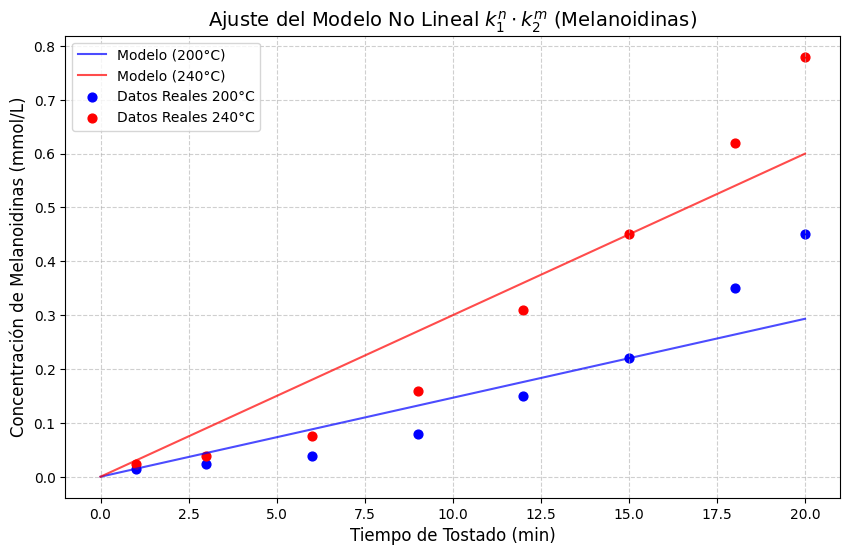

In [2]:
import numpy as np
# NumPy: manejo de arreglos y cálculos numéricos eficientes

import matplotlib.pyplot as plt
# Matplotlib: creación de gráficas científicas

# ============================
# 1. PARÁMETROS DEL MODELO
# ============================

# Estos parámetros deben haber sido obtenidos previamente con curve_fit
# Representan la mejor aproximación del modelo a los datos experimentales

t_espacio = np.linspace(0, 20, 100)
# Genera un vector de tiempo continuo entre 0 y 20 minutos
# Se usa para dibujar curvas suaves del modelo

# ============================
# 2. FUNCIÓN DE PREDICCIÓN
# ============================

def predecir(k1, k2, t):
    # Función del modelo ajustado para predecir melanoidinas

    return beta_opt * (k1**n_opt * k2**m_opt) * t
    # Modelo cinético simplificado:
    # - k1 y k2 influyen de forma no lineal (exponentes n y m)
    # - beta_opt ajusta la escala del modelo
    # - crecimiento lineal en el tiempo (t)

# ============================
# 3. DATOS EXPERIMENTALES
# ============================

tiempos_exp = np.array([1, 3, 6, 9, 12, 15, 18, 20])
# Tiempos experimentales donde se midieron melanoidinas

m_200 = np.array([0.014, 0.024, 0.039, 0.08, 0.15, 0.22, 0.35, 0.45])
# Datos experimentales de melanoidinas a 200°C

m_240 = np.array([0.024, 0.038, 0.075, 0.16, 0.31, 0.45, 0.62, 0.78])
# Datos experimentales de melanoidinas a 240°C

# ============================
# 4. CONSTRUCCIÓN DE LA GRÁFICA
# ============================

plt.figure(figsize=(10, 6))
# Crea una figura con tamaño 10x6 pulgadas

# ============================
# CURVAS DEL MODELO (PREDICCIÓN)
# ============================

plt.plot(
    t_espacio,
    predecir(0.185, 0.029, t_espacio),
    'b-',
    label='Modelo (200°C)',
    alpha=0.7
)
# Curva del modelo para 200°C:
# - usa k1=0.185 y k2=0.029
# - línea azul continua
# - alpha controla transparencia

plt.plot(
    t_espacio,
    predecir(0.269, 0.043, t_espacio),
    'r-',
    label='Modelo (240°C)',
    alpha=0.7
)
# Curva del modelo para 240°C:
# - usa k1=0.269 y k2=0.043
# - línea roja continua

# ============================
# DATOS EXPERIMENTALES (DISPERSIÓN)
# ============================

plt.scatter(
    tiempos_exp,
    m_200,
    color='blue',
    label='Datos Reales 200°C',
    s=40
)
# Puntos experimentales para 200°C

plt.scatter(
    tiempos_exp,
    m_240,
    color='red',
    label='Datos Reales 240°C',
    s=40
)
# Puntos experimentales para 240°C

# ============================
# FORMATO DE LA GRÁFICA
# ============================

plt.title(
    'Ajuste del Modelo No Lineal $k_1^n \cdot k_2^m$ (Melanoidinas)',
    fontsize=14
)
# Título de la gráfica con notación matemática

plt.xlabel('Tiempo de Tostado (min)', fontsize=12)
# Etiqueta del eje X

plt.ylabel('Concentración de Melanoidinas (mmol/L)', fontsize=12)
# Etiqueta del eje Y

plt.grid(True, linestyle='--', alpha=0.6)
# Activa la cuadrícula con estilo punteado

plt.legend()
# Muestra la leyenda para identificar curvas y datos

plt.show()
# Renderiza la gráfica final

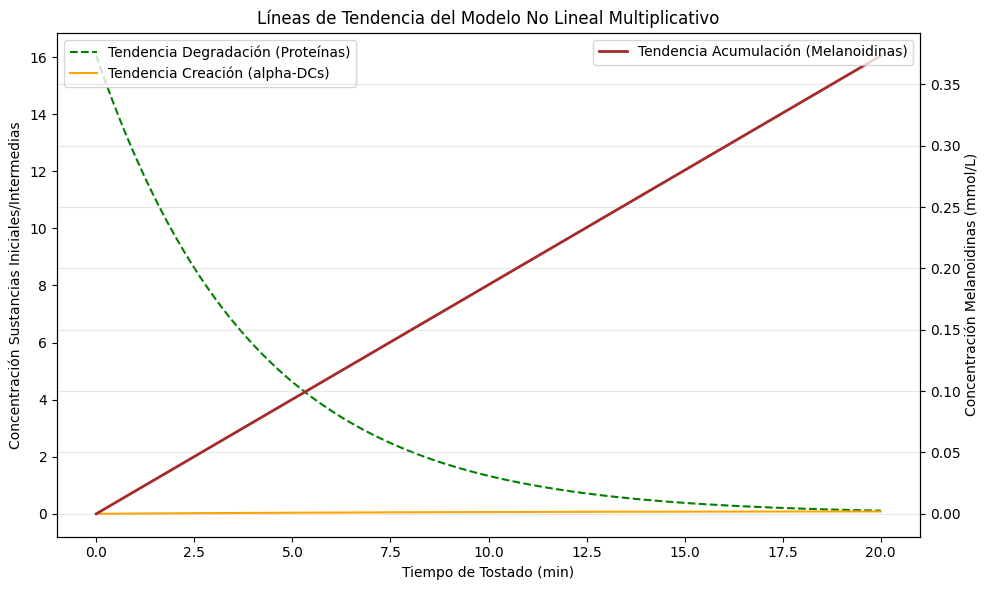

In [3]:
import numpy as np
# NumPy: permite manejo de vectores y operaciones matemáticas eficientes

import matplotlib.pyplot as plt
# Matplotlib: generación de gráficas científicas

# ============================
# 1. PARÁMETROS DEL MODELO
# ============================

# Parámetros cinéticos correspondientes a una condición (ej. 220°C)
# Estos valores representan constantes experimentales del sistema

k1, k2 = 0.249, 0.041
# k1: constante asociada a la formación de intermediarios
# k2: constante asociada al consumo hacia productos finales

t_proyeccion = np.linspace(0, 20, 100)
# Vector de tiempo continuo (0 a 20 min)
# Se usa para generar curvas suaves del modelo

# ============================
# 2. FUNCIONES DE TENDENCIA
# ============================

def degradacion_P(t):
    # Modelo de degradación de proteínas

    return 16.05 * np.exp(-k1 * t)
    # Cinética de primer orden:
    # - 16.05: concentración inicial de proteínas
    # - exp(-k1 t): decaimiento exponencial

def tendencia_A(t):
    # Modelo de formación de α-DCs (intermedios)

    return (k1**n_opt * k2**m_opt) * beta_opt * t * np.exp(-k2 * t)
    # Modelo mixto:
    # - término multiplicativo no lineal (k1^n * k2^m)
    # - beta_opt escala el sistema
    # - t genera crecimiento inicial
    # - exp(-k2 t) genera decaimiento posterior (forma de pico)

def tendencia_M(t):
    # Modelo de acumulación de melanoidinas (producto final)

    return beta_opt * (k1**n_opt * k2**m_opt) * t
    # Crecimiento aproximadamente lineal en el tiempo
    # escalado por parámetros cinéticos del modelo

# ============================
# 3. CONSTRUCCIÓN DE LA GRÁFICA
# ============================

fig, ax1 = plt.subplots(figsize=(10, 6))
# Crea figura y eje principal (ax1) con tamaño definido

# ============================
# EJE IZQUIERDO (P + A)
# ============================

ax1.plot(
    t_proyeccion,
    degradacion_P(t_proyeccion),
    'g--',
    label='Tendencia Degradación (Proteínas)'
)
# Curva verde punteada: degradación de proteínas

ax1.plot(
    t_proyeccion,
    tendencia_A(t_proyeccion) * 0.5,
    'orange',
    label='Tendencia Creación (alpha-DCs)'
)
# Curva de α-DCs:
# - escalada por 0.5 para ajuste visual
# - representa comportamiento intermedio del sistema

ax1.set_xlabel('Tiempo de Tostado (min)')
# Etiqueta eje X

ax1.set_ylabel('Concentración Sustancias Iniciales/Intermedias')
# Etiqueta eje Y del eje izquierdo

# ============================
# EJE DERECHO (MELANOIDINAS)
# ============================

ax2 = ax1.twinx()
# Crea un segundo eje Y independiente (misma X)

ax2.plot(
    t_proyeccion,
    tendencia_M(t_proyeccion),
    'brown',
    linewidth=2,
    label='Tendencia Acumulación (Melanoidinas)'
)
# Curva de melanoidinas:
# - color marrón
# - línea más gruesa para énfasis

ax2.set_ylabel('Concentración Melanoidinas (mmol/L)')
# Etiqueta del eje derecho
# ============================
# FORMATO FINAL DE LA GRÁFICA
# ============================

plt.title('Líneas de Tendencia del Modelo No Lineal Multiplicativo')
# Título general de la figura

fig.tight_layout()
# Ajusta automáticamente los espacios para evitar sobreposición

ax1.legend(loc='upper left')
# Leyenda del eje izquierdo

ax2.legend(loc='upper right')
# Leyenda del eje derecho

plt.grid(True, alpha=0.3)
# Activa rejilla suave para mejorar lectura visual

plt.show()
# Muestra la gráfica final

<>:116: SyntaxWarning: invalid escape sequence '\c'
<>:116: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_27902/3713699669.py:116: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Seguimiento Cinético: Modelo No Lineal $k_1^n \cdot k_2^m$', fontsize=14)


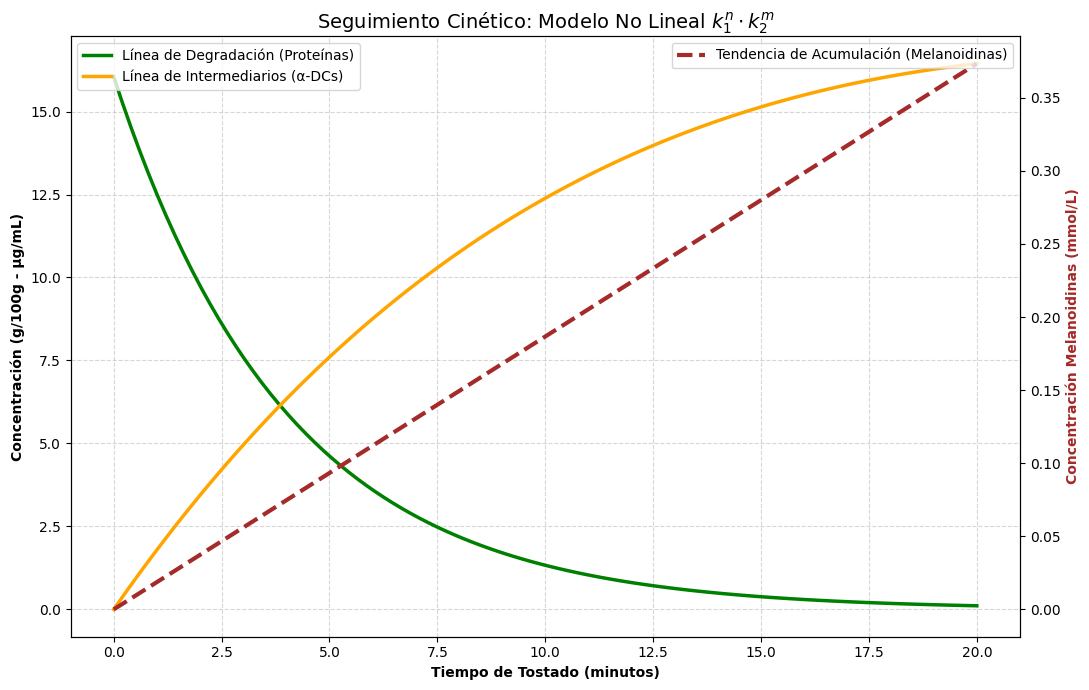

In [4]:
import numpy as np
# NumPy: permite trabajar con vectores, funciones matemáticas y operaciones numéricas eficientes

import matplotlib.pyplot as plt
# Matplotlib: librería para generar gráficas científicas de alta calidad

# ============================
# 1. PARÁMETROS DEL MODELO
# ============================

# Parámetros cinéticos del modelo para una condición específica (220°C)
# Estos valores provienen del ajuste previo del modelo no lineal

k1, k2 = 0.249, 0.041
# k1: constante cinética asociada a la formación de intermediarios
# k2: constante cinética asociada al consumo hacia productos finales

n, m, beta = n_opt, m_opt, beta_opt
# Parámetros optimizados obtenidos del ajuste:
# n → exponente de k1 (no linealidad de formación)
# m → exponente de k2 (no linealidad de consumo)
# beta → factor de escala global del modelo

t_plot = np.linspace(0, 20, 100)
# Vector de tiempo continuo (0 a 20 min)
# Permite generar curvas suaves para visualizar el comportamiento del sistema

# ============================
# 2. LÍNEAS DE TENDENCIA
# ============================

linea_degradacion = 16.05 * np.exp(-k1 * t_plot)
# Modelo de degradación de proteínas:
# - 16.05: concentración inicial
# - exp(-k1 t): cinética de primer orden (decaimiento exponencial)

linea_intermediarios = (k1**n * k2**m) * beta * 100 * t_plot * np.exp(-k2 * t_plot)
# Modelo de formación de α-DCs (intermedios):
# - término no lineal k1^n * k2^m
# - beta escala la magnitud global
# - factor 100 ajusta escala experimental
# - t genera crecimiento inicial
# - exp(-k2 t) genera caída posterior (forma tipo “campana”)

linea_acumulacion = beta * (k1**n * k2**m) * t_plot
# Modelo de acumulación de melanoidinas:
# - producto final del sistema
# - crecimiento aproximadamente lineal en el tiempo
# - modulado por parámetros cinéticos

# ============================
# 3. CONSTRUCCIÓN DE LA GRÁFICA
# ============================

fig, ax1 = plt.subplots(figsize=(11, 7))
# Crea figura principal con tamaño definido (11x7 pulgadas)

# ============================
# EJE PRINCIPAL (P + A)
# ============================

ax1.plot(
    t_plot,
    linea_degradacion,
    'g-',
    linewidth=2.5,
    label='Línea de Degradación (Proteínas)'
)
# Curva verde: comportamiento de degradación de proteínas

ax1.plot(
    t_plot,
    linea_intermediarios,
    'orange',
    linewidth=2.5,
    label='Línea de Intermediarios (α-DCs)'
)
# Curva naranja: evolución de intermediarios con forma no lineal

ax1.set_xlabel('Tiempo de Tostado (minutos)', fontweight='bold')
# Etiqueta eje X con formato resaltado

ax1.set_ylabel('Concentración (g/100g - μg/mL)', fontweight='bold')
# Etiqueta eje Y del eje principal (mezcla de escalas experimentales)

ax1.grid(True, which='both', linestyle='--', alpha=0.5)
# Activa cuadrícula para facilitar lectura de tendencias

# ============================
# EJE SECUNDARIO (MELANOIDINAS)
# ============================

ax2 = ax1.twinx()
# Crea segundo eje Y independiente (misma escala de tiempo)

ax2.plot(
    t_plot,
    linea_acumulacion,
    'brown',
    linestyle='--',
    linewidth=3,
    label='Tendencia de Acumulación (Melanoidinas)'
)
# Curva de melanoidinas:
# - color marrón
# - línea discontinua más gruesa
# - representa el producto final del sistema

ax2.set_ylabel('Concentración Melanoidinas (mmol/L)', color='brown', fontweight='bold')
# Etiqueta del eje derecho con color asociado a la curva

# ============================
# ESTÉTICA FINAL
# ============================

plt.title('Seguimiento Cinético: Modelo No Lineal $k_1^n \cdot k_2^m$', fontsize=14)
# Título con notación matemática del modelo cinético

ax1.legend(loc='upper left')
# Leyenda del eje izquierdo

ax2.legend(loc='upper right')
# Leyenda del eje derecho

plt.tight_layout()
# Ajusta automáticamente los márgenes para evitar sobreposición

plt.show()
# Muestra la gráfica final

k1 extraído: 0.185
k2 extraído: 0.029


/tmp/ipykernel_27902/2078170122.py:99: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_beta, _ = curve_fit(


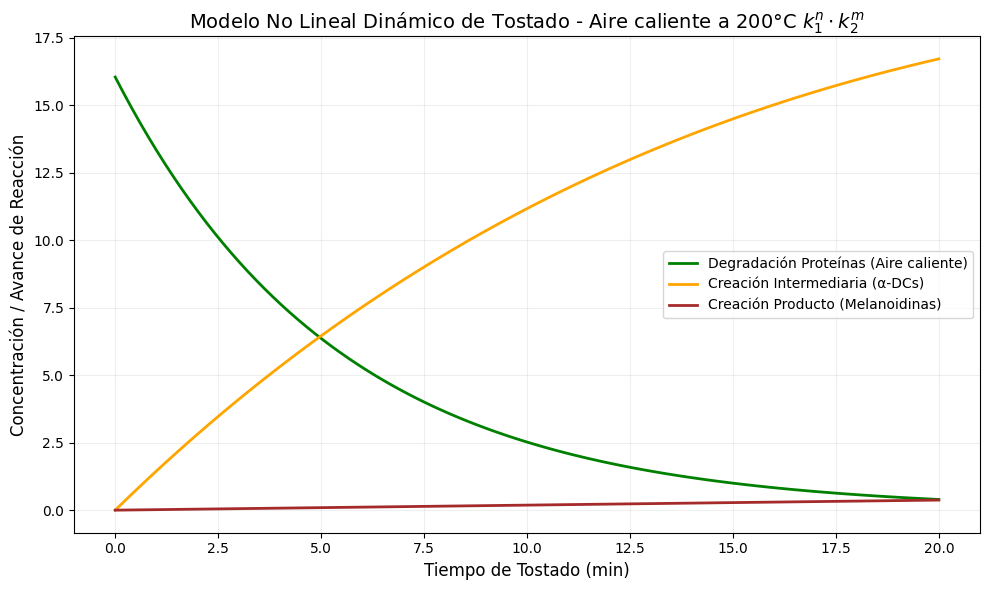


Parámetros optimizados dinámicamente para Aire caliente 200°C:
k1: 0.185000
k2: 0.029000
n: 12.1251
m: -9.7066
beta: 0.0000


In [5]:
import numpy as np
# NumPy: manejo eficiente de arreglos numéricos y operaciones matemáticas

import pandas as pd
# Pandas: lectura y manipulación de datos desde archivos Excel o CSV

import matplotlib.pyplot as plt
# Matplotlib: generación de gráficos científicos

from scipy.optimize import curve_fit
# curve_fit: ajuste de parámetros de modelos no lineales por mínimos cuadrados

# ============================
# 1. EXTRACCIÓN DINÁMICA DE DATOS
# ============================

df_ks = pd.read_excel(
    'Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx',
    sheet_name='Hoja1'
)
# Carga el archivo de constantes cinéticas (k1 y k2) para diferentes condiciones

df_ml = pd.read_excel(
    'Datos para entrenar el modelo de machine learning.xlsx',
    sheet_name='Hoja1'
)
# Carga el archivo de datos experimentales para entrenamiento del modelo ML

df_ks['Método de asado'] = df_ks['Método de asado'].ffill()
# Rellena valores faltantes hacia adelante en la columna método de asado

df_ks['Compuestos'] = df_ks['Compuestos'].ffill()
# Rellena valores faltantes en la columna compuestos (evita NaN en filtros)

# ============================
# FUNCIÓN DE EXTRACCIÓN DE PARÁMETROS
# ============================

def obtener_parametros_dinamicos(metodo, temp_col):
    # Función que extrae dinámicamente k1 y k2 desde la base de datos

    k1 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &
        (df_ks['Compuestos'] == ' α-DCs') &
        (df_ks['Parametros'] == 'k1')
    ][temp_col].values[0])
    # Extrae k1 filtrando por método, compuesto y temperatura

    k2 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &
        (df_ks['Compuestos'] == ' α-DCs') &
        (df_ks['Parametros'] == 'k2')
    ][temp_col].values[0])
    # Extrae k2 con el mismo criterio de filtrado

    return k1, k2
    # Retorna ambos parámetros cinéticos

# ============================
# 2. CONFIGURACIÓN DEL ESCENARIO
# ============================

METODO = 'Aire caliente'
# Método de tostado seleccionado

TEMPERATURA = '200°C'
# Temperatura específica del análisis (puede cambiar dinámicamente)

k1, k2 = obtener_parametros_dinamicos(METODO, TEMPERATURA)
# Obtiene los parámetros cinéticos desde los datos experimentales

print(f"k1 extraído: {k1}")
print(f"k2 extraído: {k2}")
# Verificación inmediata de los parámetros cargados

# Datos experimentales de referencia para ajuste del modelo

m_real = 0.28
# Valor experimental de melanoidinas

t_ref = 15
# Tiempo de referencia para calibración del modelo

# ============================
# 3. MODELO CINÉTICO REDUCIDO
# ============================

def modelo_dinamico_single_param(t, beta):
    # Modelo simplificado donde solo beta es ajustado

    return beta * (k1**n_opt * k2**m_opt) * t
    # Estructura del modelo:
    # - k1^n_opt y k2^m_opt capturan no linealidad cinética
    # - beta ajusta escala global
    # - dependencia lineal con el tiempo

# Ajuste de beta usando un único punto experimental

popt_beta, _ = curve_fit(
    modelo_dinamico_single_param,
    [t_ref],        # tiempo de referencia
    [m_real],       # dato experimental
    p0=[4.5]        # valor inicial de beta
)

beta_opt = popt_beta[0]
# Parámetro beta optimizado

# ============================
# 4. SIMULACIÓN DEL SISTEMA
# ============================

t_plot = np.linspace(0, 20, 100)
# Vector de tiempo continuo para simulación del modelo

degradacion = 16.05 * np.exp(-k1 * t_plot)
# Modelo de degradación de proteínas (cinética de primer orden)

creacion_intermediarios = (
    (k1**n_opt * k2**m_opt) * beta_opt * 80 * t_plot * np.exp(-k2 * t_plot)
)
# Modelo de formación de α-DCs:
# - crecimiento inicial (t)
# - decaimiento exponencial (exp(-k2 t))
# - modulado por cinética no lineal


creacion_producto = modelo_dinamico_single_param(t_plot, beta_opt)
# Modelo de formación de melanoidinas usando beta calibrado

# ============================
# 5. GRÁFICA DEL MODELO
# ============================

plt.figure(figsize=(10, 6))
# Figura con tamaño definido


plt.plot(
    t_plot,
    degradacion,
    'g-',
    label=f'Degradación Proteínas ({METODO})',
    linewidth=2
)
# Curva verde: degradación de proteínas

plt.plot(
    t_plot,
    creacion_intermediarios,
    'orange',
    label='Creación Intermediaria (α-DCs)',
    linewidth=2
)
# Curva naranja: intermediarios de reacción

plt.plot(
    t_plot,
    creacion_producto,
    'brown',
    label='Creación Producto (Melanoidinas)',
    linewidth=2
)
# Curva marrón: producto final del sistema

plt.title(
    f'Modelo No Lineal Dinámico de Tostado - {METODO} a {TEMPERATURA} $k_1^n \\cdot k_2^m$',
    fontsize=14
)
# Título con notación matemática del modelo cinético


plt.xlabel('Tiempo de Tostado (min)', fontsize=12)
# Etiqueta eje X

plt.ylabel('Concentración / Avance de Reacción', fontsize=12)
# Etiqueta eje Y

plt.grid(True, alpha=0.2)
# Cuadrícula ligera para mejorar lectura

plt.legend()
# Muestra leyenda de las curvas

plt.tight_layout()
# Ajusta automáticamente la distribución de la figura

plt.show()
# Renderiza la gráfica final

# ============================
# 6. RESULTADOS NUMÉRICOS
# ============================

print(f"\nParámetros optimizados dinámicamente para {METODO} {TEMPERATURA}:")
# Encabezado de resultados

print(f"k1: {k1:.6f}")
# Constante cinética k1

print(f"k2: {k2:.6f}")
# Constante cinética k2

print(f"n: {n_opt:.4f}")
# Exponente no lineal asociado a k1

print(f"m: {m_opt:.4f}")
# Exponente no lineal asociado a k2

print(f"beta: {beta_opt:.4f}")
# Factor de escala del modelo

k1 extraído: 0.249
k2 extraído: 0.041


/tmp/ipykernel_27902/2730207803.py:63: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_beta, _ = curve_fit(


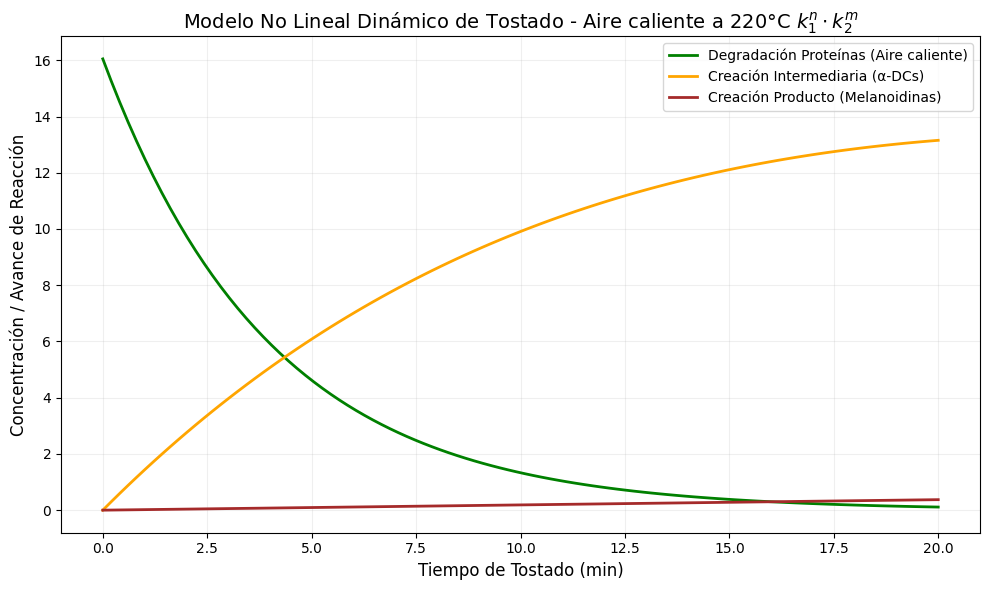


Parámetros optimizados dinámicamente para Aire caliente 220°C:
k1: 0.249000
k2: 0.041000
n: 12.1251
m: -9.7066
beta: 0.0000


In [6]:
import numpy as np  # Importa NumPy para manejo de arreglos y operaciones matemáticas
import pandas as pd  # Importa pandas para manipulación de datos tipo tabla (Excel)
import matplotlib.pyplot as plt  # Importa matplotlib para generación de gráficos
from scipy.optimize import curve_fit  # Importa función para ajuste de parámetros no lineales

# --- 1. EXTRACCIÓN DINÁMICA DE DATOS ---

df_ks = pd.read_excel(  # Carga archivo Excel con constantes cinéticas del modelo
    'Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx',
    sheet_name='Hoja1'
)

df_ml = pd.read_excel(  # Carga archivo Excel con datos para machine learning (no usado en este bloque)
    'Datos para entrenar el modelo de machine learning.xlsx',
    sheet_name='Hoja1'
)

df_ks['Método de asado'] = df_ks['Método de asado'].ffill()  # Rellena valores faltantes del método de asado hacia adelante
df_ks['Compuestos'] = df_ks['Compuestos'].ffill()  # Rellena valores faltantes de compuestos hacia adelante

# Función para extraer constantes cinéticas k1 y k2 desde la base de datos
def obtener_parametros_dinamicos(metodo, temp_col):
    """Extrae k1 y k2 dinámicamente del Excel de constantes."""

    # Filtra k1 según método, compuesto y temperatura
    k1 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &  # Condición 1: método de tostado
        (df_ks['Compuestos'] == ' α-DCs') &     # Condición 2: compuesto específico
        (df_ks['Parametros'] == 'k1')           # Condición 3: parámetro k1
    ][temp_col].values[0])  # Toma el primer valor encontrado

    # Filtra k2 según las mismas condiciones pero para k2
    k2 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &  # Método de asado
        (df_ks['Compuestos'] == ' α-DCs') &     # Compuesto α-DCs
        (df_ks['Parametros'] == 'k2')           # Parámetro k2
    ][temp_col].values[0])  # Extrae valor numérico

    return k1, k2  # Retorna constantes cinéticas

# --- 2. CONFIGURACIÓN DEL ESCENARIO ---

METODO = 'Aire caliente'  # Define el método de tostado a analizar
TEMPERATURA = '220°C'  # Define la temperatura del proceso

k1, k2 = obtener_parametros_dinamicos(METODO, TEMPERATURA)  # Extrae k1 y k2 según condiciones

# Verificación inmediata de valores extraídos desde Excel
print(f"k1 extraído: {k1}")  # Imprime k1 para validación
print(f"k2 extraído: {k2}")  # Imprime k2 para validación

# Datos experimentales de referencia
m_real = 0.28  # Valor experimental del producto final (melanoidinas)
t_ref = 15  # Tiempo de referencia experimental

# --- 3. MODELO CINÉTICO ---

# Define el modelo dinámico con un solo parámetro ajustable beta
def modelo_dinamico_single_param(t, beta):
    return beta * (k1**n_opt * k2**m_opt) * t  # Ecuación cinética del modelo

# Ajuste del parámetro beta usando mínimos cuadrados no lineales
popt_beta, _ = curve_fit(
    modelo_dinamico_single_param,  # modelo definido
    [t_ref],  # dato independiente (tiempo)
    [m_real],  # dato dependiente (concentración real)
    p0=[4.5]  # valor inicial estimado de beta
)

beta_opt = popt_beta[0]  # Extrae el valor óptimo de beta

# --- 4. SIMULACIÓN DEL SISTEMA ---

t_plot = np.linspace(0, 20, 100)  # Genera vector de tiempo de 0 a 20 min

# Modelo de degradación de proteínas (cinética de primer orden)
degradacion = 16.05 * np.exp(-k1 * t_plot)  # Decaimiento exponencial

# Formación de intermediarios (α-DCs) con dependencia cinética doble
creacion_intermediarios = (
    (k1**n_opt * k2**m_opt) *  # efecto combinado de constantes cinéticas
    beta_opt *                # factor de ajuste del modelo
    80 *                      # escala empírica
    t_plot *                  # dependencia temporal lineal
    np.exp(-k2 * t_plot)     # decaimiento por k2
)

# Formación del producto final (melanoidinas)
creacion_producto = modelo_dinamico_single_param(t_plot, beta_opt)

# --- 5. VISUALIZACIÓN DE RESULTADOS ---

plt.figure(figsize=(10, 6))  # Define tamaño de la figura

# Curva de degradación de proteínas
plt.plot(
    t_plot, degradacion, 'g-',  # color verde
    label=f'Degradación Proteínas ({METODO})',
    linewidth=2
)

# Curva de formación de intermediarios
plt.plot(
    t_plot, creacion_intermediarios, 'orange',
    label='Creación Intermediaria (α-DCs)',
    linewidth=2
)

# Curva de producto final
plt.plot(
    t_plot, creacion_producto, 'brown',
    label='Creación Producto (Melanoidinas)',
    linewidth=2
)

# Título del gráfico con notación matemática del modelo
plt.title(
    f'Modelo No Lineal Dinámico de Tostado - {METODO} a {TEMPERATURA} $k_1^n \\cdot k_2^m$',
    fontsize=14
)

plt.xlabel('Tiempo de Tostado (min)', fontsize=12)  # Etiqueta eje X
plt.ylabel('Concentración / Avance de Reacción', fontsize=12)  # Etiqueta eje Y

plt.grid(True, alpha=0.2)  # Activa rejilla suave
plt.legend()  # Muestra leyenda
plt.tight_layout()  # Ajusta automáticamente márgenes
plt.show()  # Muestra gráfico

# --- 6. RESULTADOS FINALES ---

print(f"\nParámetros optimizados dinámicamente para {METODO} {TEMPERATURA}:")
print(f"k1: {k1:.6f}")  # Imprime constante k1
print(f"k2: {k2:.6f}")  # Imprime constante k2
print(f"n: {n_opt:.4f}")  # Exponente n optimizado (debe estar definido previamente)
print(f"m: {m_opt:.4f}")  # Exponente m optimizado (debe estar definido previamente)
print(f"beta: {beta_opt:.4f}")  # Parámetro ajustado del modelo

k1 extraído: 0.269
k2 extraído: 0.043


/tmp/ipykernel_27902/3650183474.py:86: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_beta, _ = curve_fit(


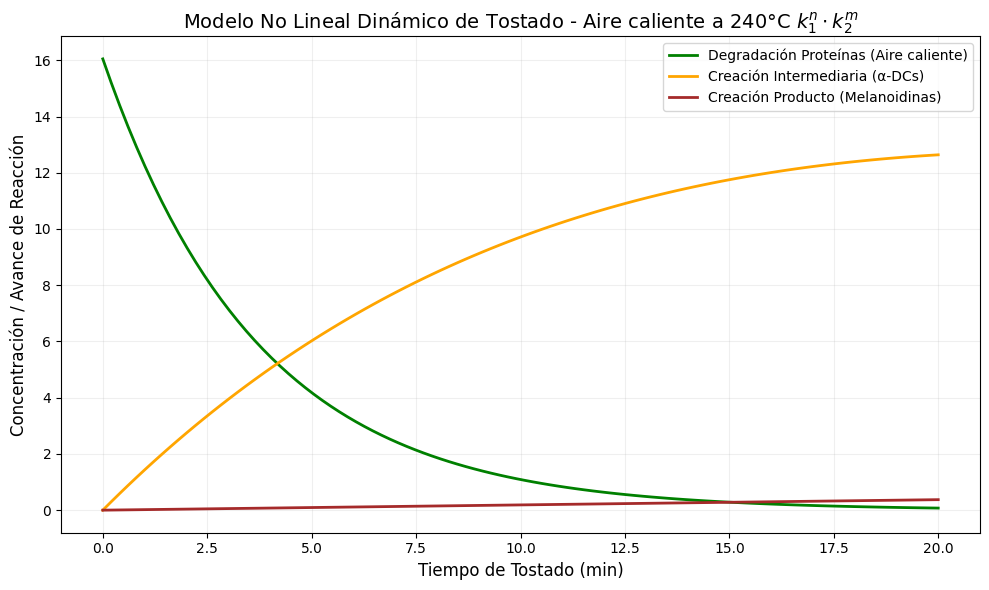


Parámetros optimizados dinámicamente para Aire caliente 240°C:
k1: 0.269000
k2: 0.043000
n: 12.1251
m: -9.7066
beta: 0.0000


In [7]:
import numpy as np  # Librería para cálculo numérico y manejo de arreglos matemáticos
import pandas as pd  # Librería para manipulación y análisis de datos tipo tabla (Excel)
import matplotlib.pyplot as plt  # Librería para generación de gráficos científicos
from scipy.optimize import curve_fit  # Función para ajuste de parámetros en modelos no lineales

# ============================================================
# 1. EXTRACCIÓN DINÁMICA DE DATOS DESDE ARCHIVOS EXCEL
# ============================================================

df_ks = pd.read_excel(  # Carga el archivo con constantes cinéticas del modelo
    'Datos para entrenar el modelo constantes de velocidad para el modelo cinético.xlsx',
    sheet_name='Hoja1'
)

df_ml = pd.read_excel(  # Carga el archivo de machine learning (no utilizado en este bloque)
    'Datos para entrenar el modelo de machine learning.xlsx',
    sheet_name='Hoja1'
)

# Rellena valores faltantes hacia adelante para mantener continuidad en variables categóricas
df_ks['Método de asado'] = df_ks['Método de asado'].ffill()
df_ks['Compuestos'] = df_ks['Compuestos'].ffill()

# ============================================================
# 2. FUNCIÓN DE EXTRACCIÓN DE PARÁMETROS CINÉTICOS
# ============================================================

def obtener_parametros_dinamicos(metodo, temp_col):
    """
    Extrae las constantes cinéticas k1 y k2 desde la base de datos,
    filtrando por método de asado, compuesto y temperatura.
    """

    # Extracción de k1 bajo condiciones específicas del sistema
    k1 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &   # Filtra por método de tostado
        (df_ks['Compuestos'] == ' α-DCs') &      # Selecciona el compuesto α-DCs
        (df_ks['Parametros'] == 'k1')            # Selecciona el parámetro k1
    ][temp_col].values[0])  # Extrae el primer valor encontrado

    # Extracción de k2 bajo las mismas condiciones pero para el parámetro k2
    k2 = float(df_ks[
        (df_ks['Método de asado'] == metodo) &   # Método de tostado
        (df_ks['Compuestos'] == ' α-DCs') &      # Compuesto α-DCs
        (df_ks['Parametros'] == 'k2')            # Parámetro k2
    ][temp_col].values[0])  # Conversión a float del valor extraído

    return k1, k2  # Retorna las constantes cinéticas del sistema

# ============================================================
# 3. CONFIGURACIÓN DEL ESCENARIO DE SIMULACIÓN
# ============================================================

METODO = 'Aire caliente'  # Define el método de tostado a analizar
TEMPERATURA = '240°C'  # Define la temperatura del proceso

# Obtención de constantes cinéticas según el escenario definido
k1, k2 = obtener_parametros_dinamicos(METODO, TEMPERATURA)

# Verificación inmediata de valores extraídos desde Excel
print(f"k1 extraído: {k1}")  # Muestra k1 para control de calidad
print(f"k2 extraído: {k2}")  # Muestra k2 para control de calidad

# ============================================================
# 4. CONDICIONES EXPERIMENTALES DE REFERENCIA
# ============================================================

m_real = 0.28  # Valor experimental del producto final (melanoidinas)
t_ref = 15  # Tiempo de referencia experimental en minutos

# ============================================================
# 5. DEFINICIÓN DEL MODELO CINÉTICO
# ============================================================

def modelo_dinamico_single_param(t, beta):
    """
    Modelo cinético simplificado donde:
    - beta es el único parámetro ajustable
    - k1 y k2 son constantes del sistema
    - n_opt y m_opt son exponentes previamente definidos (externamente)
    """

    return beta * (k1**n_opt * k2**m_opt) * t  # Ecuación del modelo dinámico

# Ajuste del parámetro beta mediante optimización no lineal
popt_beta, _ = curve_fit(
    modelo_dinamico_single_param,  # modelo matemático
    [t_ref],  # variable independiente (tiempo)
    [m_real],  # variable dependiente (dato experimental)
    p0=[4.5]  # valor inicial estimado para beta
)

beta_opt = popt_beta[0]  # Valor óptimo del parámetro beta

# ============================================================
# 6. SIMULACIÓN DEL SISTEMA CINÉTICO
# ============================================================

t_plot = np.linspace(0, 20, 100)  # Genera vector de tiempo continuo

# Modelo de degradación de proteínas (cinética exponencial de primer orden)
degradacion = 16.05 * np.exp(-k1 * t_plot)

# Formación de intermediarios (α-DCs) con cinética dependiente de k1 y k2
creacion_intermediarios = (
    (k1**n_opt * k2**m_opt) *  # contribución cinética combinada
    beta_opt *                # parámetro ajustado del modelo
    80 *                      # factor de escala empírico
    t_plot *                  # dependencia lineal con el tiempo
    np.exp(-k2 * t_plot)     # decaimiento asociado a k2
)

# Formación del producto final (melanoidinas)
creacion_producto = modelo_dinamico_single_param(t_plot, beta_opt)

# ============================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ============================================================

plt.figure(figsize=(10, 6))  # Tamaño de la figura

# Curva de degradación de proteínas
plt.plot(
    t_plot, degradacion, 'g-',  # línea verde
    label=f'Degradación Proteínas ({METODO})',
    linewidth=2
)

# Curva de intermediarios (α-DCs)
plt.plot(
    t_plot, creacion_intermediarios, 'orange',
    label='Creación Intermediaria (α-DCs)',
    linewidth=2
)

# Curva del producto final (melanoidinas)
plt.plot(
    t_plot, creacion_producto, 'brown',
    label='Creación Producto (Melanoidinas)',
    linewidth=2
)

# Título del gráfico con notación matemática del modelo
plt.title(
    f'Modelo No Lineal Dinámico de Tostado - {METODO} a {TEMPERATURA} $k_1^n \\cdot k_2^m$',
    fontsize=14
)

plt.xlabel('Tiempo de Tostado (min)', fontsize=12)  # Eje X
plt.ylabel('Concentración / Avance de Reacción', fontsize=12)  # Eje Y

plt.grid(True, alpha=0.2)  # Cuadrícula suave
plt.legend()  # Leyenda del gráfico
plt.tight_layout()  # Ajuste automático de márgenes
plt.show()  # Mostrar figura

# ============================================================
# 8. RESULTADOS FINALES DEL MODELO
# ============================================================

print(f"\nParámetros optimizados dinámicamente para {METODO} {TEMPERATURA}:")
print(f"k1: {k1:.6f}")  # Constante cinética k1
print(f"k2: {k2:.6f}")  # Constante cinética k2
print(f"n: {n_opt:.4f}")  # Exponente n (debe estar definido previamente)
print(f"m: {m_opt:.4f}")  # Exponente m (debe estar definido previamente)
print(f"beta: {beta_opt:.4f}")  # Parámetro ajustado del modelo